In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
students = {
    "Name": ["Ali", "Aysel", "Murad", "Leyla"],
    "Math": [85, 92, 70, 95],
    "English": [78, 88, 65, 90]
}

df = pd.DataFrame(students)

df

,Name,Math,English
0,Ali,85,78
1,Aysel,92,88
2,Murad,70,65
3,Leyla,95,90


In [3]:
df.describe()

,Math,English
count,4.000000,4.000000
mean,85.500000,80.250000
std,11.150486,11.441882
min,70.000000,65.000000
25%,81.250000,74.750000
50%,88.500000,83.000000
75%,92.750000,88.500000
max,95.000000,90.000000


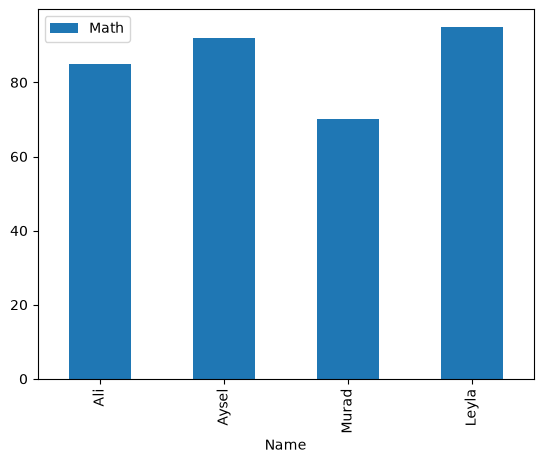

In [4]:
df.plot(x="Name", y="Math", kind="bar")
plt.show()

In [5]:
data = {
    "study_hours": [2, 3, 1, 5, 4, 6, 2, 7, 8, 3],
    "attendance": [60, 70, 55, 90, 85, 95, 65, 98, 100, 75],
    "previous_score": [50, 60, 45, 80, 75, 88, 55, 92, 96, 65],
    "passed": [0, 0, 0, 1, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
df.to_csv("../data/student_data.csv", index=False)

df

,study_hours,attendance,previous_score,passed
0,2,60,50,0
1,3,70,60,0
2,1,55,45,0
3,5,90,80,1
4,4,85,75,1
5,6,95,88,1
6,2,65,55,0
7,7,98,92,1
8,8,100,96,1
9,3,75,65,0


In [6]:
df = pd.read_csv("../data/student_data.csv")
df.head()

,study_hours,attendance,previous_score,passed
0,2,60,50,0
1,3,70,60,0
2,1,55,45,0
3,5,90,80,1
4,4,85,75,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     10 non-null     int64
 1   attendance      10 non-null     int64
 2   previous_score  10 non-null     int64
 3   passed          10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [8]:
df.describe()

,study_hours,attendance,previous_score,passed
count,10.000000,10.00000,10.00000,10.000000
mean,4.100000,79.30000,70.60000,0.500000
std,2.330951,16.47928,18.19768,0.527046
min,1.000000,55.00000,45.00000,0.000000
25%,2.250000,66.25000,56.25000,0.000000
50%,3.500000,80.00000,70.00000,0.500000
75%,5.750000,93.75000,86.00000,1.000000
max,8.000000,100.00000,96.00000,1.000000


In [9]:
df["passed"].value_counts()

passed
0    5
1    5
Name: count, dtype: int64

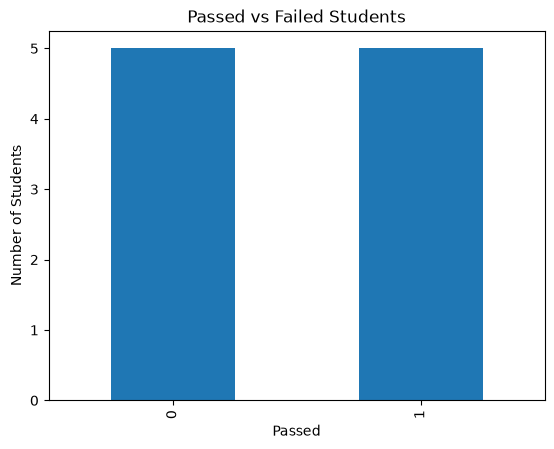

In [10]:
df["passed"].value_counts().plot(kind="bar")
plt.xlabel("Passed")
plt.ylabel("Number of Students")
plt.title("Passed vs Failed Students")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [12]:
X = df[["study_hours", "attendance", "previous_score"]]
y = df["passed"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [15]:
predictions = model.predict(X_test)

print(predictions)

[1 0]


In [16]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [17]:
new_student = [[4, 85, 78]]

result = model.predict(new_student)

print(result)

[1]


/Users/sariyagasimova/AI-Engineer-Portfolio/01-student-performance-predictor/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
